# 1. CV analysis

In [46]:
import importlib
import os
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
importlib.reload(config)
from viz_style import apply_style
apply_style()

CV = Path('./CV_Results_mixed')
ENG = Path('./engine_state_mixed')
FIG = CV / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)

# Reference values a correctly-specified normative model must hit on held-out HC (a true null).
TARGET = {'mean_z': 0.0, 'std_z': 1.0, 'exceed': 0.05, 'med_z2': 0.4549}  # med_z2 = median of chi2(df=1)

NZ_BINS = [24, 30, 40, 50, 60, 80, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 676]
NZ_LABELS = [
    f'{NZ_BINS[i]+1}={NZ_BINS[i+1]}' for i in range(0, len(NZ_BINS)-1)
]

In [47]:
# 0. Load CV artifacts
fold = pd.read_csv(CV / 'fold_stats.csv')
pool_fold = pd.read_csv(CV / 'pool_fold_stats.csv')
cv = pd.read_csv(CV / 'cv_stats.csv')
train = pd.read_csv(ENG / 'training_summary.csv')

# per-gene fold stability: a gene is "stable" only if the individual GLMM converged in all 5 folds
stab = fold.groupby('gene')['ok'].sum().rename('n_fold_ok').reset_index()
cv = cv.merge(stab, on='gene', how='left')
cv['stable'] = cv['n_fold_ok'] == config.SPIKE_PARAMS['n_splits']
cv['nz_bin'] = pd.cut(cv['nz'], bins=NZ_BINS, labels=NZ_LABELS)
cv['route_stage'] = cv['route'] + '/' + cv['stage']

print(f"engine ok genes: {int(train['ok'].sum())} | cv_stats rows: {len(cv)} "
      f"(missing {int(train['ok'].sum()) - len(cv)}: all folds failed)")
print(f"model route: {int((cv.route == 'model').sum())} | pool route: {int((cv.route == 'pool').sum())}")
print(f"\npool-route fold fits (one shared GLMM per fold):\n{pool_fold.to_string(index=False)}")
display(cv.groupby('route_stage').agg(
    n=('gene', 'size'), nz_med=('nz', 'median'), mean_z=('mean_z', 'mean'), std_z=('std_z', 'mean'),
    exceed=('cv_naive_exceed', 'mean'), stable=('stable', 'mean')).round(4))

engine ok genes: 19858 | cv_stats rows: 19858 (missing 0: all folds failed)
model route: 17798 | pool route: 2060

pool-route fold fits (one shared GLMM per fold):
 fold   ok family  fail_reason
    0 True negbin          NaN
    1 True negbin          NaN
    2 True negbin          NaN
    3 True negbin          NaN
    4 True negbin          NaN


,n,nz_med,mean_z,std_z,exceed,stable
route_stage,,,,,,
model/nbi_full_eb,17752,564.0,0.0058,1.0185,0.0544,0.9836
model/nbi_intercept_eb,46,46.5,0.0283,1.0015,0.0488,0.1739
pool/pool,2060,13.0,-0.0008,0.9484,0.0395,0.0000


model-route fold success: 0.9948 (88530/88990)
genes converging in all 5 folds: 0.9815

train-stage routing (deployed engine):
route     stage           
excluded  nbi_intercept_eb      239
model     nbi_full_eb         17752
          nbi_intercept_eb       46
pool      pool                 2060

fold fail_reason:
fail_reason
not_converged_or_explosion_or_tau2_bound    460


,n_gene,fold_ok,all5_ok
nz_bin,,,
31=40,412,0.9257,0.7403
41=50,354,0.9508,0.8277
51=60,354,0.9633,0.8757
61=80,604,0.9795,0.9238
81=100,522,0.9870,0.9521
101=150,991,0.9950,0.9788
151=200,799,0.9950,0.9812
201=250,628,0.9978,0.9920
251=300,554,0.9986,0.9946


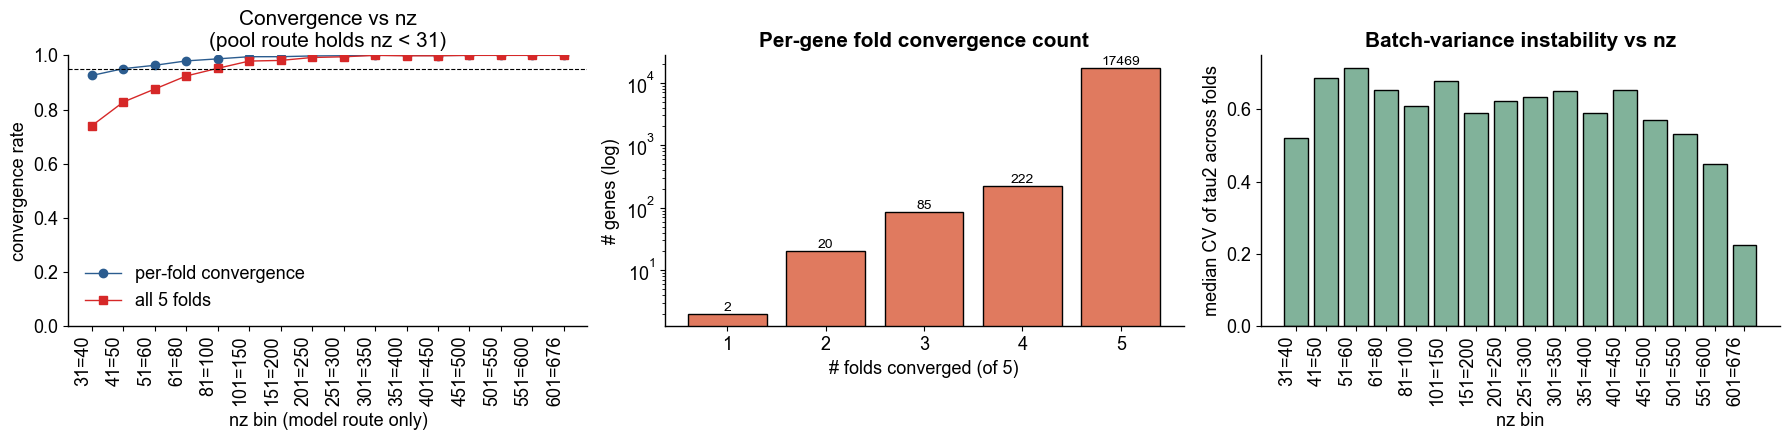

In [55]:
fold_nz = fold.merge(train[['gene', 'nz']], on='gene')
fold_nz['nz_bin'] = pd.cut(fold_nz['nz'], bins=NZ_BINS, labels=NZ_LABELS)
by_nz = fold_nz.groupby('nz_bin', observed=True).agg(n_gene=('gene', 'nunique'), fold_ok=('ok', 'mean'))
by_nz['all5_ok'] = cv[cv.route == 'model'].groupby('nz_bin', observed=True)['stable'].mean()

print(f"model-route fold success: {fold['ok'].mean():.4f} ({int(fold['ok'].sum())}/{len(fold)})")
print(f"genes converging in all 5 folds: {cv.loc[cv.route == 'model', 'stable'].mean():.4f}")
print(f"\ntrain-stage routing (deployed engine):\n"
      f"{train.groupby(['route', 'stage'], dropna=False).size().to_string()}")
print(f"\nfold fail_reason:\n{fold.loc[~fold['ok'], 'fail_reason'].fillna('(blank)').value_counts().to_string()}")
display(by_nz.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
x = np.arange(len(by_nz))
axes[0].plot(x, by_nz['fold_ok'], marker='o', color='#2b5c8f', label='per-fold convergence')
axes[0].plot(x, by_nz['all5_ok'], marker='s', color='#d62828', label='all 5 folds')
axes[0].axhline(0.95, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x); axes[0].set_xticklabels(by_nz.index, rotation=90, ha='right')
axes[0].set_ylabel('convergence rate'); axes[0].set_xlabel('nz bin (model route only)')
axes[0].set_title(f'Convergence vs nz\n(pool route holds nz < {config.NZ_A_MAX})')
axes[0].set_ylim(0, 1)
axes[0].legend(frameon=False)

nfold = cv.loc[cv.route == 'model', 'n_fold_ok'].value_counts().sort_index()
axes[1].bar(nfold.index.astype(int), nfold.values, color='#e07a5f', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_xlabel('# folds converged (of 5)'); axes[1].set_ylabel('# genes (log)')
axes[1].set_title('Per-gene fold convergence count',fontweight='bold')
for i, v in zip(nfold.index.astype(int), nfold.values):
    axes[1].text(i, v, str(int(v)), ha='center', va='bottom') 

# tau2 is refit per fold; its spread across folds is a second, continuous stability read-out that
# does not depend on the binary convergence flag.
t2 = fold_nz[fold_nz['ok']].groupby('gene').agg(tau2_cv=('tau2', lambda v: v.std() / max(v.mean(), 1e-9)),
                                                nz=('nz', 'first'))
t2['nz_bin'] = pd.cut(t2['nz'], bins=NZ_BINS, labels=NZ_LABELS)
med = t2.groupby('nz_bin', observed=True)['tau2_cv'].median()
axes[2].bar(np.arange(len(med)), med.values, color='#81b29a', edgecolor='black')
axes[2].set_xticks(np.arange(len(med))); axes[2].set_xticklabels(med.index, rotation=90, ha='right')
axes[2].set_ylabel('median CV of tau2 across folds'); axes[2].set_xlabel('nz bin')
axes[2].set_title('Batch-variance instability vs nz',fontweight='bold')

plt.tight_layout(); plt.savefig(FIG / 'cv_convergence.png', dpi=150, bbox_inches='tight'); plt.show()

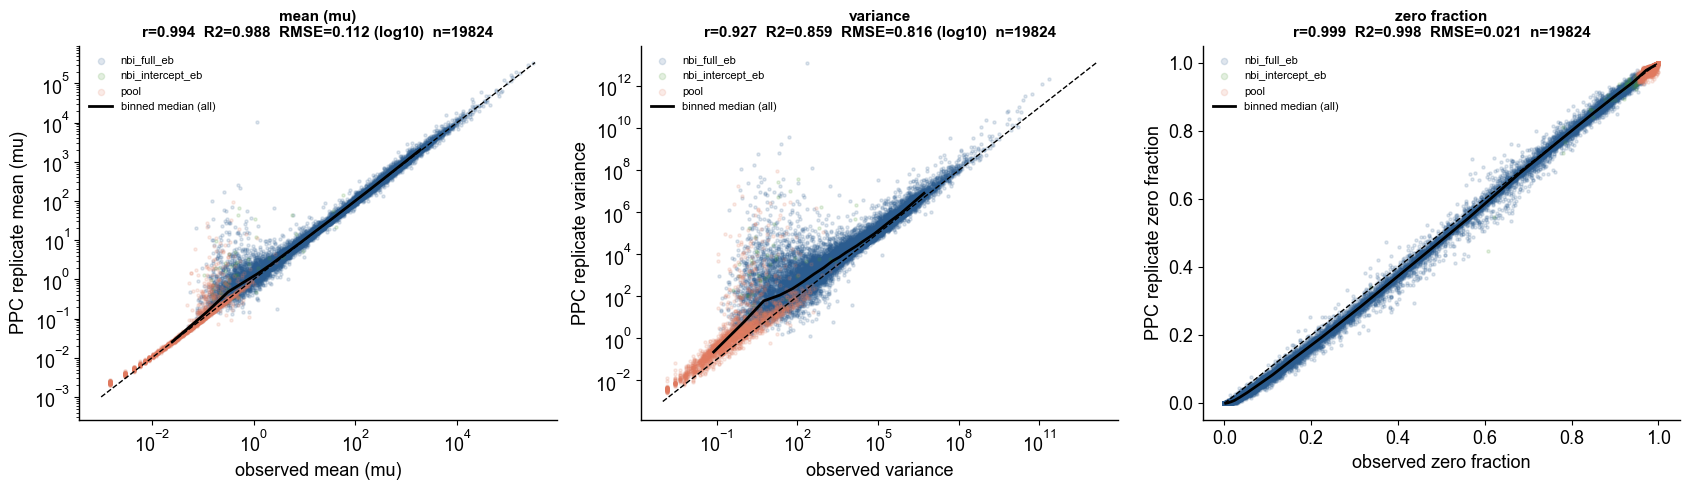

held-out calibration, CV-based PPC replicates (log10 scale for mean/var, linear for zero):
  mean (mu)      (all)   : r=0.9942  R2=0.9884  RMSE=0.1122  n=19824
  mean (mu)      (nbi_full_eb     ): r=0.9938  R2=0.9877  RMSE=0.1088  n=17752
  mean (mu)      (nbi_intercept_eb): r=0.6816  R2=0.4646  RMSE=0.5027  n=46
  mean (mu)      (pool            ): r=0.5390  R2=0.2905  RMSE=0.1166  n=2026
  variance       (all)   : r=0.9269  R2=0.8592  RMSE=0.8160  n=19824
  variance       (nbi_full_eb     ): r=0.9117  R2=0.8313  RMSE=0.7940  n=17752
  variance       (nbi_intercept_eb): r=0.4763  R2=0.2268  RMSE=2.8359  n=46
  variance       (pool            ): r=0.5929  R2=0.3516  RMSE=0.8997  n=2026
  zero fraction  (all)   : r=0.9992  R2=0.9984  RMSE=0.0207  n=19824
  zero fraction  (nbi_full_eb     ): r=0.9989  R2=0.9979  RMSE=0.0217  n=17752
  zero fraction  (nbi_intercept_eb): r=0.9772  R2=0.9550  RMSE=0.0299  n=46
  zero fraction  (pool            ): r=0.8282  R2=0.6859  RMSE=0.0075  n=2026


In [49]:
from MixedEffectsModeling.validation.ppc_simulate import simulate_marginal_nb

PPC_N_REPS = 200
CAL_CACHE = CV / 'cv_calibration_moments.csv'
if CAL_CACHE.exists():
    cal = pd.read_csv(CAL_CACHE)
else:
    ppcd = pickle.load(open(CV / 'cv_ppc.pkl', 'rb'))
    rows = []
    for i, (g, d) in enumerate(ppcd.items()):
        y = np.asarray(d['y'], float); mu = np.asarray(d['mu'], float)
        alpha = np.asarray(d['alpha'], float); tau2 = np.asarray(d['tau2'], float)
        if y.size == 0 or not (np.isfinite(mu).all() and np.isfinite(alpha).all() and np.isfinite(tau2).all()):
            continue
        y_rep = simulate_marginal_nb(mu, alpha, tau2, PPC_N_REPS, seed=1000 + i)
        rows.append({'gene': g, 'obs_mean': y.mean(), 'pred_mean': y_rep.mean(1).mean(),
                     'obs_var': y.std(), 'pred_var': y_rep.std(1).mean(),
                     'obs_zero': (y == 0).mean(), 'pred_zero': (y_rep == 0).mean(1).mean()})
    cal = pd.DataFrame(rows)
    cal.to_csv(CAL_CACHE, index=False)
cal = cal.merge(cv[['gene', 'route', 'stage']], on='gene', how='left')
STAGE_COLOR = {'nbi_full_eb': '#2b5c8f', 'nbi_intercept_eb': "#499831", 'pool': '#e07a5f'}

def calib_stats(o, p, logscale):
    o, p = np.asarray(o, float), np.asarray(p, float)
    m = np.isfinite(o) & np.isfinite(p)
    o, p = o[m], p[m]
    if logscale:
        o, p = np.log10(o + 1), np.log10(p + 1)
    r = np.corrcoef(o, p)[0, 1]
    return r, r ** 2, np.sqrt(np.mean((p - o) ** 2)), len(o)

def binned(o, p, nb=20):
    o, p = np.asarray(o, float), np.asarray(p, float)
    m = np.isfinite(o) & np.isfinite(p) & (o > 0)
    o, p = o[m], p[m]
    q = np.unique(np.quantile(o, np.linspace(0, 1, nb + 1)))
    idx = np.clip(np.digitize(o, q[1:-1]), 0, len(q) - 2)
    return (np.array([np.median(o[idx == k]) for k in range(len(q) - 1)]),
            np.array([np.median(p[idx == k]) for k in range(len(q) - 1)]))

panels = [('obs_mean', 'pred_mean', 'mean (mu)', True),
          ('obs_var', 'pred_var', 'variance', True),
          ('obs_zero', 'pred_zero', 'zero fraction', False)]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (oc, pc, lab, logsc) in zip(axes, panels):
    for stage, col in STAGE_COLOR.items():
        s = cal[cal.stage == stage]
        ax.scatter(s[oc], s[pc], s=5, alpha=0.15, color=col, label=stage)
    bx, by = binned(cal[oc], cal[pc])
    ax.plot(bx, by, '-', color='black', linewidth=2, label='binned median (all)')
    if logsc:
        lo = max(min(cal[oc].min(), cal[pc].min()), 1e-3); hi = max(cal[oc].max(), cal[pc].max())
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1); ax.set_xscale('log'); ax.set_yscale('log')
    else:
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    r, r2, rmse, n = calib_stats(cal[oc], cal[pc], logsc)
    unit = ' (log10)' if logsc else ''
    ax.set_title(f'{lab}\nr={r:.3f}  R2={r2:.3f}  RMSE={rmse:.3f}{unit}  n={n}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'observed {lab}'); ax.set_ylabel(f'PPC replicate {lab}')
    ax.legend(frameon=False, fontsize=8, markerscale=2)
plt.tight_layout(); plt.savefig(FIG / 'cv_ppc_replicates.png', dpi=150, bbox_inches='tight'); plt.show()

print('held-out calibration, CV-based PPC replicates (log10 scale for mean/var, linear for zero):')
for oc, pc, lab, logsc in panels:
    r, r2, rmse, n = calib_stats(cal[oc], cal[pc], logsc)
    print(f'  {lab:14s} (all)   : r={r:.4f}  R2={r2:.4f}  RMSE={rmse:.4f}  n={n}')
    for stage in STAGE_COLOR:
        sub = cal[cal.stage == stage]
        r, r2, rmse, n = calib_stats(sub[oc], sub[pc], logsc)
        print(f'  {lab:14s} ({stage:16s}): r={r:.4f}  R2={r2:.4f}  RMSE={rmse:.4f}  n={n}')

In [50]:
from scipy.stats import kurtosis, norm, skew

from MixedEffectsModeling.core.calibration import bh_fdr_reject
from MixedEffectsModeling.core.shash import fit_shash, shash_transform_to_z

SHASH_NESTED_PATH = CV / 'cv_gene_shash_nested.csv'
N_SHASH_FOLDS = 5
Q_LEVELS = (0.05, 0.01)

if SHASH_NESTED_PATH.exists():
    shn = pd.read_csv(SHASH_NESTED_PATH)
else:
    zdict = pickle.load(open(CV / 'cv_zscores.pkl', 'rb'))
    params = cv.set_index('gene')[['cv_shash_ok', 'cv_shash_xi', 'cv_shash_eta', 'cv_shash_eps', 'cv_shash_delta']]
    rng = np.random.default_rng(42)
    rows = []
    for g, z in zdict.items():
        z = z[np.isfinite(z)].astype(np.float64)
        if len(z) < 20 or g not in params.index:
            continue
        row = {'gene': g, 'n_valid': len(z)}

        pv_raw = 2 * norm.sf(np.abs(z))
        for q in Q_LEVELS:
            row[f'raw_n_out_q{int(q * 100):02d}'] = int(bh_fdr_reject(pv_raw, q=q).sum())

        p = params.loc[g]
        z_ins = shash_transform_to_z(z, p.cv_shash_xi, p.cv_shash_eta, p.cv_shash_eps, p.cv_shash_delta) if p.cv_shash_ok else z
        row['ins_mean'] = float(np.mean(z_ins)); row['ins_std'] = float(np.std(z_ins))
        row['ins_skew'] = float(skew(z_ins)); row['ins_kurt'] = float(kurtosis(z_ins))
        pv_ins = 2 * norm.sf(np.abs(z_ins))
        for q in Q_LEVELS:
            row[f'ins_n_out_q{int(q * 100):02d}'] = int(bh_fdr_reject(pv_ins, q=q).sum())

        idx = rng.permutation(len(z))
        folds = np.array_split(idx, N_SHASH_FOLDS)
        z_nested = z.copy()
        for k in range(N_SHASH_FOLDS):
            test_idx = folds[k]
            train_idx = np.concatenate([folds[j] for j in range(N_SHASH_FOLDS) if j != k])
            xi, eta, eps, delta, ok = fit_shash(z[train_idx])
            if ok:
                z_nested[test_idx] = shash_transform_to_z(z[test_idx], xi, eta, eps, delta)
        row['nested_mean'] = float(np.mean(z_nested)); row['nested_std'] = float(np.std(z_nested))
        row['nested_skew'] = float(skew(z_nested)); row['nested_kurt'] = float(kurtosis(z_nested))
        pv_nested = 2 * norm.sf(np.abs(z_nested))
        for q in Q_LEVELS:
            row[f'nested_n_out_q{int(q * 100):02d}'] = int(bh_fdr_reject(pv_nested, q=q).sum())

        rows.append(row)
    shn = pd.DataFrame(rows)
    shn.to_csv(SHASH_NESTED_PATH, index=False)

print(f'saved -> {SHASH_NESTED_PATH}  ({len(shn)} genes)')

saved -> CV_Results_mixed/cv_gene_shash_nested.csv  (19824 genes)


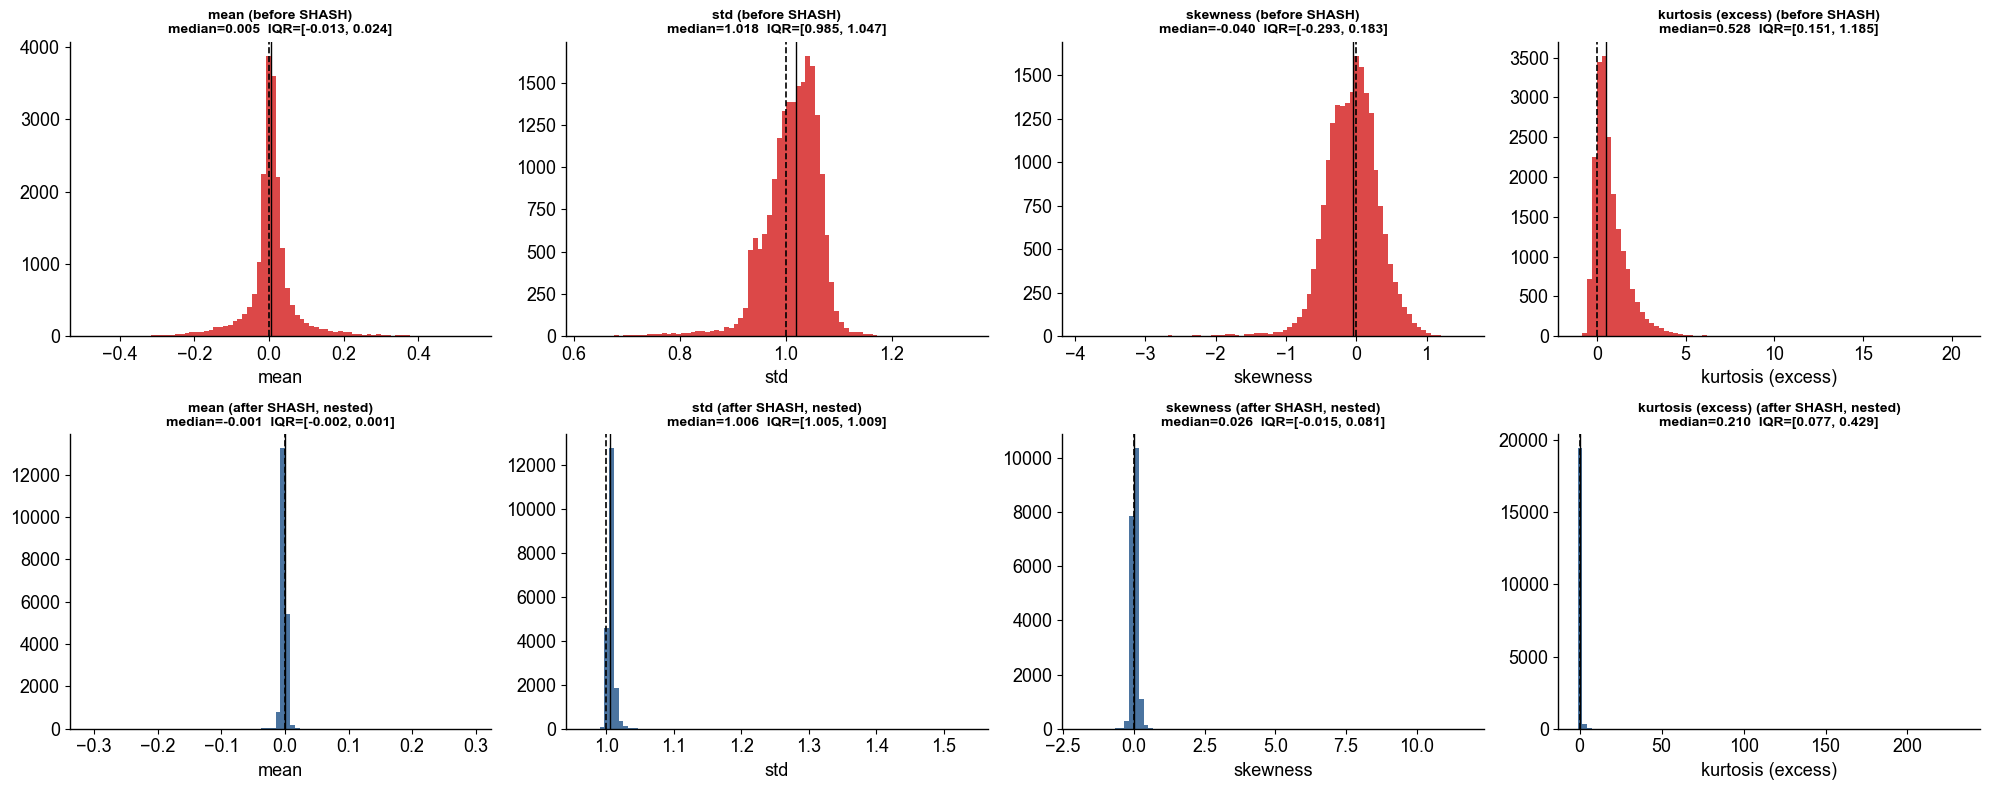

SHASH calibration, held-out CV, nested-holdout corrected (median [IQR]):
  mean               ideal=+0.0  before=+0.0047 [-0.0128, +0.0243]   after=-0.0007 [-0.0023, +0.0008]
  std                ideal=+1.0  before=+1.0182 [+0.9846, +1.0471]   after=+1.0065 [+1.0046, +1.0090]
  skewness           ideal=+0.0  before=-0.0400 [-0.2927, +0.1832]   after=+0.0260 [-0.0153, +0.0805]
  kurtosis (excess)  ideal=+0.0  before=+0.5283 [+0.1513, +1.1854]   after=+0.2105 [+0.0773, +0.4289]


In [51]:
cv2 = cv.merge(shn[['gene', 'ins_mean', 'ins_std', 'ins_skew', 'ins_kurt',
                    'nested_mean', 'nested_std', 'nested_skew', 'nested_kurt']], on='gene', how='left')

metrics = [('mean', 'mean_z', 'nested_mean', 0.0),
          ('std', 'std_z', 'nested_std', 1.0),
          ('skewness', 'cv_raw_skew', 'nested_skew', 0.0),
          ('kurtosis (excess)', 'cv_raw_kurtosis', 'nested_kurt', 0.0)]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for col, (lab, raw_c, corr_c, ideal) in enumerate(metrics):
    for row, (c, title, color) in enumerate([(raw_c, f'{lab} (before SHASH)', '#d62828'),
                                              (corr_c, f'{lab} (after SHASH, nested)', '#2b5c8f')]):
        ax = axes[row, col]
        v = cv2[c].dropna()
        ax.hist(v, bins=80, color=color, edgecolor='none', alpha=0.85)
        ax.axvline(ideal, color='black', linewidth=1.2, linestyle='--')
        ax.axvline(v.median(), color='black', linewidth=1.0)
        ax.set_title(f'{title}\nmedian={v.median():.3f}  IQR=[{v.quantile(.25):.3f}, {v.quantile(.75):.3f}]',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel(lab)
plt.tight_layout(); plt.savefig(FIG / 'cv_shash_before_after.png', dpi=150, bbox_inches='tight'); plt.show()

print('SHASH calibration, held-out CV, nested-holdout corrected (median [IQR]):')
for lab, raw_c, corr_c, ideal in metrics:
    r, c = cv2[raw_c].dropna(), cv2[corr_c].dropna()
    print(f'  {lab:18s} ideal={ideal:+.1f}  before={r.median():+.4f} [{r.quantile(.25):+.4f}, {r.quantile(.75):+.4f}]'
         f'   after={c.median():+.4f} [{c.quantile(.25):+.4f}, {c.quantile(.75):+.4f}]')

genes with >=1 BH outlier -- raw vs in-sample vs nested-holdout SHASH:
  q=0.05: genes flagged raw=11209 (0.5654)  in-sample=5755 (0.2903)  nested=9316 (0.4699)  | total outlier samples raw=28245  in-sample=7721  nested=13878
  q=0.01: genes flagged raw=7703 (0.3886)  in-sample=2155 (0.1087)  nested=5276 (0.2661)  | total outlier samples raw=13710  in-sample=2365  nested=6431


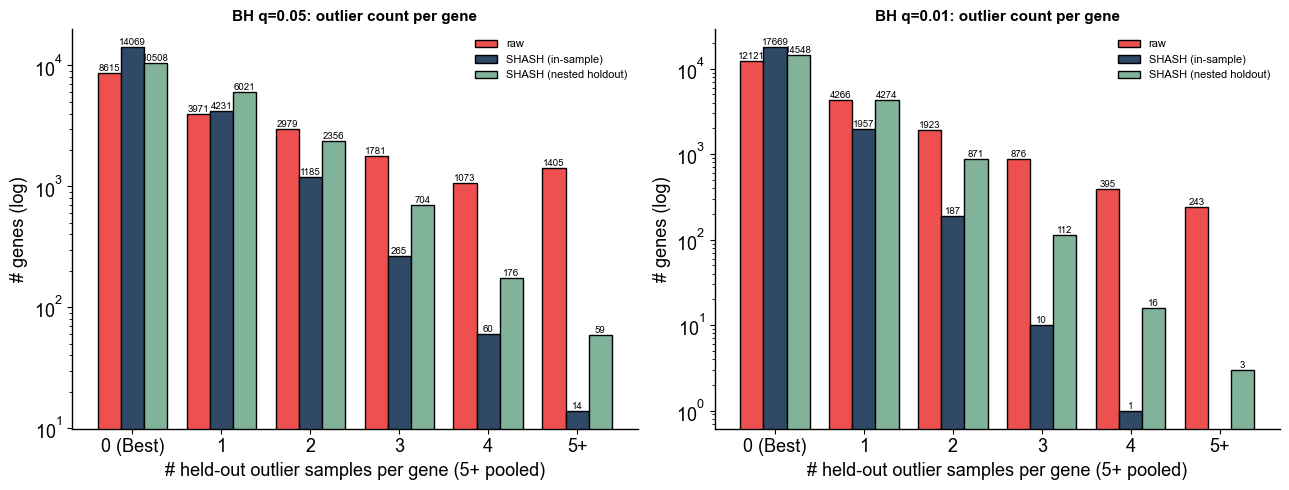

In [52]:
CAT_LABELS = ['0 (Best)', '1', '2', '3', '4', '5+']

def categorize(s):
    return pd.cut(s.clip(upper=5), bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5], labels=CAT_LABELS)

print('genes with >=1 BH outlier -- raw vs in-sample vs nested-holdout SHASH:')
for q in Q_LEVELS:
    qtag = f'q{int(q * 100):02d}'
    n_raw = (shn[f'raw_n_out_{qtag}'] > 0).sum()
    n_ins = (shn[f'ins_n_out_{qtag}'] > 0).sum()
    n_nest = (shn[f'nested_n_out_{qtag}'] > 0).sum()
    print(f'  q={q:.2f}: genes flagged raw={n_raw} ({n_raw/len(shn):.4f})  '
         f'in-sample={n_ins} ({n_ins/len(shn):.4f})  nested={n_nest} ({n_nest/len(shn):.4f})'
         f'  | total outlier samples raw={shn[f"raw_n_out_{qtag}"].sum()}'
         f'  in-sample={shn[f"ins_n_out_{qtag}"].sum()}  nested={shn[f"nested_n_out_{qtag}"].sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(CAT_LABELS)); w = 0.26
for ax, q in zip(axes, Q_LEVELS):
    qtag = f'q{int(q * 100):02d}'
    n_raw = categorize(shn[f'raw_n_out_{qtag}']).value_counts().reindex(CAT_LABELS).values
    n_ins = categorize(shn[f'ins_n_out_{qtag}']).value_counts().reindex(CAT_LABELS).values
    n_nest = categorize(shn[f'nested_n_out_{qtag}']).value_counts().reindex(CAT_LABELS).values
    bars = [ax.bar(x + off, vals, w, color=c, edgecolor='black', label=lab)
           for off, vals, c, lab in [(-w, n_raw, '#ee5050', 'raw'),
                                     (0, n_ins, '#2f4966', 'SHASH (in-sample)'),
                                     (w, n_nest, '#81b29a', 'SHASH (nested holdout)')]]
    ax.set_yscale('log')
    for group in bars:
        for bar in group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h, f'{int(h)}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(CAT_LABELS)
    ax.set_xlabel('# held-out outlier samples per gene (5+ pooled)'); ax.set_ylabel('# genes (log)')
    ax.set_title(f'BH q={q:.2f}: outlier count per gene', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG / 'cv_bh_outlier_raw_ins_nested.png', dpi=150, bbox_inches='tight'); plt.show()

/tmp/ipykernel_54883/1209972148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,
/tmp/ipykernel_54883/1209972148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,
/tmp/ipykernel_54883/1209972148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,


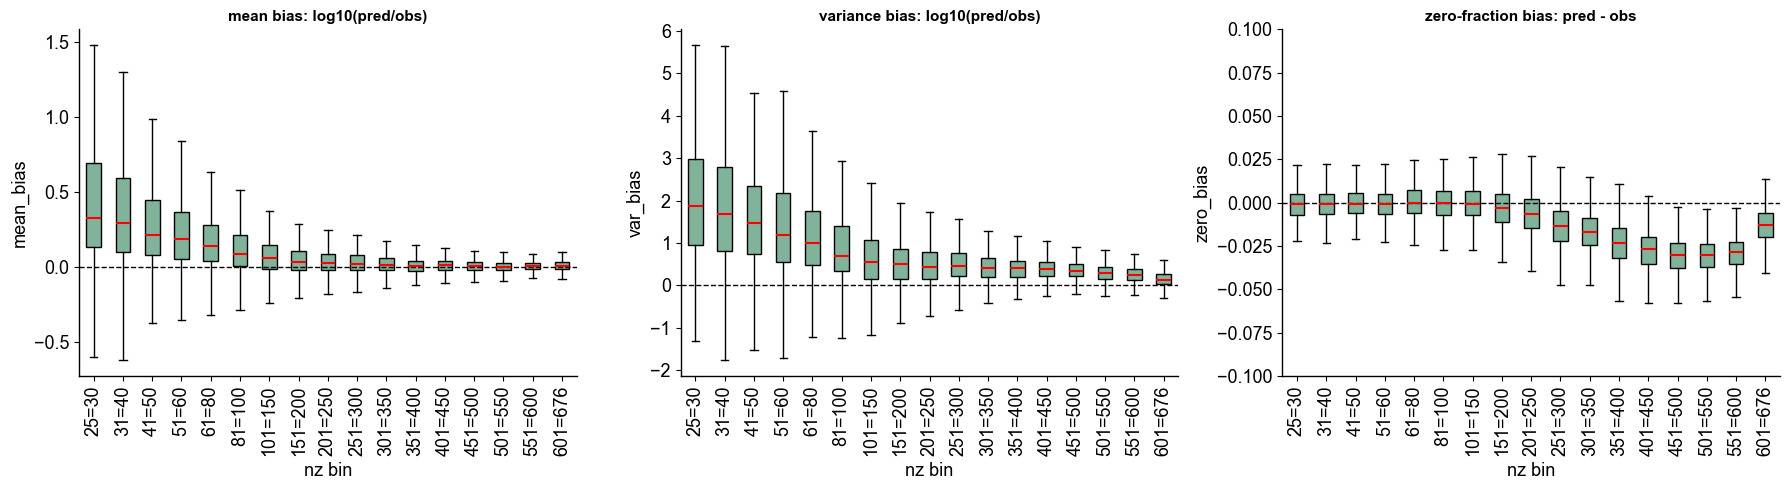

excluded (pool route, below first nz bin): 1759


,mean_bias,var_bias,zero_bias
nz_bin,,,
25=30,0.3265,1.8710,-0.0008
31=40,0.2931,1.6802,-0.0008
41=50,0.2159,1.4633,-0.0006
51=60,0.1867,1.1872,-0.0010
61=80,0.1425,1.0092,-0.0002
81=100,0.0842,0.6964,-0.0000
101=150,0.0572,0.5535,-0.0008
151=200,0.0347,0.4962,-0.0031
201=250,0.0233,0.4242,-0.0064


In [53]:
bias = pd.read_csv(CV / 'cv_calibration_moments.csv').merge(cv[['gene', 'nz', 'nz_bin']], on='gene', how='left')
bias['mean_bias'] = np.log10(np.maximum(bias.pred_mean, 1e-8) / np.maximum(bias.obs_mean, 1e-8))
bias['var_bias'] = np.log10(np.maximum(bias.pred_var, 1e-8) / np.maximum(bias.obs_var, 1e-8))
bias['zero_bias'] = bias.pred_zero - bias.obs_zero

bins_present = [b for b in NZ_LABELS if bias.nz_bin.eq(b).any()]
panels = [('mean_bias', 'mean bias: log10(pred/obs)'),
         ('var_bias', 'variance bias: log10(pred/obs)'),
         ('zero_bias', 'zero-fraction bias: pred - obs')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title) in zip(axes, panels):
    data = [bias.loc[bias.nz_bin == b, col].dropna().values for b in bins_present]
    ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,
              boxprops=dict(facecolor='#81b29a', color='black'),
              medianprops=dict(color='red', linewidth=1.5))
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('nz bin'); ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=90)
    if col == 'zero_bias':
        ax.set_ylim(-0.1, 0.1)
plt.tight_layout(); plt.savefig(FIG / 'cv_ppc_bias_vs_nz.png', dpi=150, bbox_inches='tight'); plt.show()

print(f'excluded (pool route, below first nz bin): {bias.nz_bin.isna().sum()}')
display(bias.groupby('nz_bin', observed=True)[['mean_bias', 'var_bias', 'zero_bias']].median().round(4))